# Notebook 4: Statistical Analysis and Predictive Modelling

## In this notebook, the following activities are conducted

- The final 100-company analytical dataset is loaded and validated.
- Descriptive statistics and distribution plots are produced for the eight NLP features and Final RQI.
- Variable normality is assessed using the Shapiro–Wilk test.
- Potential outliers are identified using the interquartile-range method.
- Spearman correlations between the eight NLP features and Final RQI are examined.
- Multiple-testing results are adjusted using the Benjamini–Hochberg procedure.
- Relationships among the predictors are examined and multicollinearity is assessed using the Variance Inflation Factor.
- Sector-based differences in Final RQI are tested using the Kruskal–Wallis test.
- The eight NLP features are treated as independent variables, Final RQI is treated as the dependent variable and TRBC Sector is retained as the control variable.
- The dataset is divided into training and testing samples using a fixed random seed of 42.
- Multiple Linear Regression is developed as the baseline model.
- Random Forest and XGBoost models are developed to examine non-linear relationships.
- Five-fold cross-validation and model tuning are applied.
- Model performance is evaluated using MAE, RMSE and R-squared.
- The predictive models are compared and the most influential NLP features are identified.
- Final model predictions are exported for external validation in Notebook 5.

**Sample size:** 100 companies  
**Independent variables:** Eight NLP features  
**Dependent variable:** Final Reporting Quality Index  
**Control variable:** TRBC Sector  
**Training and testing split:** 80:20  
**Cross-validation:** Five folds  
**Fixed random seed:** 42  
**Models:** Multiple Linear Regression, Random Forest and XGBoost  
**Evaluation measures:** MAE, RMSE and R-squared  
**Main output file:** `Notebook05_Final_Model_Predictions.xlsx`  

**Next stage:** External validation against LSEG ESG scores in Notebook 5.

## 1. Set Up the Project and Load the Analytical Dataset

The project folders are defined and the final 100-company analytical dataset produced in Notebook 3 is loaded for statistical analysis and predictive modelling.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
PROJECT_COLOUR = "#1F4E78"

PROJECT_FOLDER = Path.home() / "Desktop" / "ESGProjectAnalysis"
DATA_FOLDER = PROJECT_FOLDER / "data"
OUTPUT_FOLDER = PROJECT_FOLDER / "output"

input_file = (
    DATA_FOLDER / "Notebook04_Final_Analytical_Dataset.xlsx"
)

if not input_file.exists():
    raise FileNotFoundError(f"Input file not found: {input_file}")

analysis_df = pd.read_excel(input_file)

print(f"Companies loaded: {len(analysis_df)}")
print(f"Dataset shape: {analysis_df.shape}")

display(analysis_df.head())

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.stats import gaussian_kde


Companies loaded: 100
Dataset shape: (100, 18)


,Final Sample ID,Sample ID,RIC,Company Name,TRBC Sector,LSEG ESG Score,Report Year,Report Type,Word Count,ESG Keyword Density,Flesch Reading Ease,Sentiment Score,Lexical Diversity,Jargon Density,Thematic Richness,Quantitative Disclosure Density,Raw RQI Score,Final RQI
0,F001,FTSE-001,ATYM.L,Atalaya Mining Copper SA,Basic Materials,3.033797,2025,Annual Report,100097,1.118915,19.997259,0.936436,0.074620,0.389622,7,63.158736,10,62.50
1,F002,FTSE-003,CRDA.L,Croda International PLC,Basic Materials,3.686486,2025,Annual Report,138145,1.874842,29.447269,0.901310,0.077171,1.404322,8,76.593434,14,87.50
2,F003,FTSE-004,GLEN.L,Glencore PLC,Basic Materials,3.812741,2025,Annual Report,171251,3.287572,21.688613,0.887620,0.057865,0.543063,6,114.697140,10,62.50
3,F004,FTSE-005,HILS.L,Hill & Smith PLC,Basic Materials,2.492386,2025,Annual Report,111959,2.393733,32.278196,0.850640,0.076895,0.643093,6,76.572674,10,62.50
4,F005,FTSE-006,MNDI.L,Mondi PLC,Basic Materials,3.625000,2023,Annual Report,134849,2.721563,24.763780,0.974427,0.070570,0.652582,8,74.957916,13,81.25


## 2. Validate the Analytical Dataset

The dataset is checked for the required variables, sample size, duplicate companies, missing values and numerical consistency before the statistical analysis begins.

In [2]:
nlp_features = [
    "Word Count",
    "ESG Keyword Density",
    "Flesch Reading Ease",
    "Sentiment Score",
    "Lexical Diversity",
    "Jargon Density",
    "Thematic Richness",
    "Quantitative Disclosure Density"
]

target_variable = "Final RQI"
control_variable = "TRBC Sector"

required_columns = [
    "Company Name",
    control_variable,
    "LSEG ESG Score",
    target_variable
] + nlp_features

missing_columns = [
    column for column in required_columns
    if column not in analysis_df.columns
]

if missing_columns:
    raise KeyError(f"Missing columns: {missing_columns}")

analysis_df[nlp_features + [target_variable, "LSEG ESG Score"]] = (
    analysis_df[nlp_features + [target_variable, "LSEG ESG Score"]]
    .apply(pd.to_numeric, errors="coerce")
)

validation_summary = pd.DataFrame({
    "Validation Check": [
        "Companies loaded",
        "Unique company names",
        "NLP features available",
        "Duplicate companies",
        "Missing required values",
        "Infinite numerical values"
    ],
    "Result": [
        len(analysis_df),
        analysis_df["Company Name"].nunique(),
        len(nlp_features),
        analysis_df["Company Name"].duplicated().sum(),
        int(analysis_df[required_columns].isna().sum().sum()),
        int(np.isinf(
            analysis_df[nlp_features + [target_variable]]
        ).sum().sum())
    ]
})

display(validation_summary.style.hide(axis="index"))

if (
    len(analysis_df) != 100
    or analysis_df["Company Name"].nunique() != 100
    or len(nlp_features) != 8
    or analysis_df[required_columns].isna().sum().sum() > 0
    or np.isinf(
        analysis_df[nlp_features + [target_variable]]
    ).any().any()
):
    raise ValueError("Analytical dataset validation failed.")

print("Analytical dataset validation passed.")

Validation Check,Result
Companies loaded,100
Unique company names,100
NLP features available,8
Duplicate companies,0
Missing required values,0
Infinite numerical values,0


Analytical dataset validation passed.


## 3. Produce Descriptive Statistics

Descriptive statistics are calculated for the eight NLP features and Final RQI. The results summarise the sample size, central tendency, dispersion, range and distributional shape of each analytical variable.



In [3]:
analytical_variables = nlp_features + [target_variable]

descriptive_statistics = (
    analysis_df[analytical_variables]
    .describe()
    .T
    .rename(columns={
        "count": "N",
        "mean": "Mean",
        "std": "Standard Deviation",
        "min": "Minimum",
        "25%": "Q1",
        "50%": "Median",
        "75%": "Q3",
        "max": "Maximum"
    })
)

descriptive_statistics["Skewness"] = (
    analysis_df[analytical_variables].skew()
)

descriptive_statistics = (
    descriptive_statistics[
        [
            "N",
            "Mean",
            "Standard Deviation",
            "Minimum",
            "Q1",
            "Median",
            "Q3",
            "Maximum",
            "Skewness"
        ]
    ]
    .reset_index()
    .rename(columns={"index": "Variable"})
)

descriptive_statistics.to_excel(
    DATA_FOLDER / "Notebook04_Descriptive_Statistics.xlsx",
    index=False
)

display(
    descriptive_statistics.round(4).style.hide(axis="index")
)

print(
    "Results saved as: "
    "Notebook04_Descriptive_Statistics.xlsx"
)

Variable,N,Mean,Standard Deviation,Minimum,Q1,Median,Q3,Maximum,Skewness
Word Count,100.000000,100120.670000,57979.727700,7131.000000,58310.500000,102177.000000,129411.500000,349301.000000,1.107400
ESG Keyword Density,100.000000,2.049500,1.424400,0.000000,1.158200,1.804100,2.411700,7.150300,1.988700
Flesch Reading Ease,100.000000,28.956700,5.672900,5.958000,25.530400,30.609400,32.592200,38.976700,-1.466200
Sentiment Score,100.000000,0.893600,0.081300,0.561700,0.862400,0.901100,0.943500,0.999600,-1.292800
Lexical Diversity,100.000000,0.101700,0.048500,0.041100,0.076400,0.083300,0.115000,0.304900,2.213500
Jargon Density,100.000000,0.625900,0.333200,0.000000,0.423900,0.544500,0.763000,1.831800,1.276800
Thematic Richness,100.000000,5.490000,1.997400,0.000000,4.000000,6.000000,7.000000,8.000000,-0.904600
Quantitative Disclosure Density,100.000000,75.777200,17.275900,30.344100,66.199600,76.583100,82.804200,163.203700,1.231600
Final RQI,100.000000,60.937500,22.036700,6.250000,50.000000,68.750000,75.000000,93.750000,-0.764800


Results saved as: Notebook04_Descriptive_Statistics.xlsx


## 4. Visualise the Analytical Variable Distributions

The distributions of the eight NLP features and Final RQI are presented using histograms and density curves. The visualisations support the assessment of central tendency, skewness, dispersion and potential extreme observations.

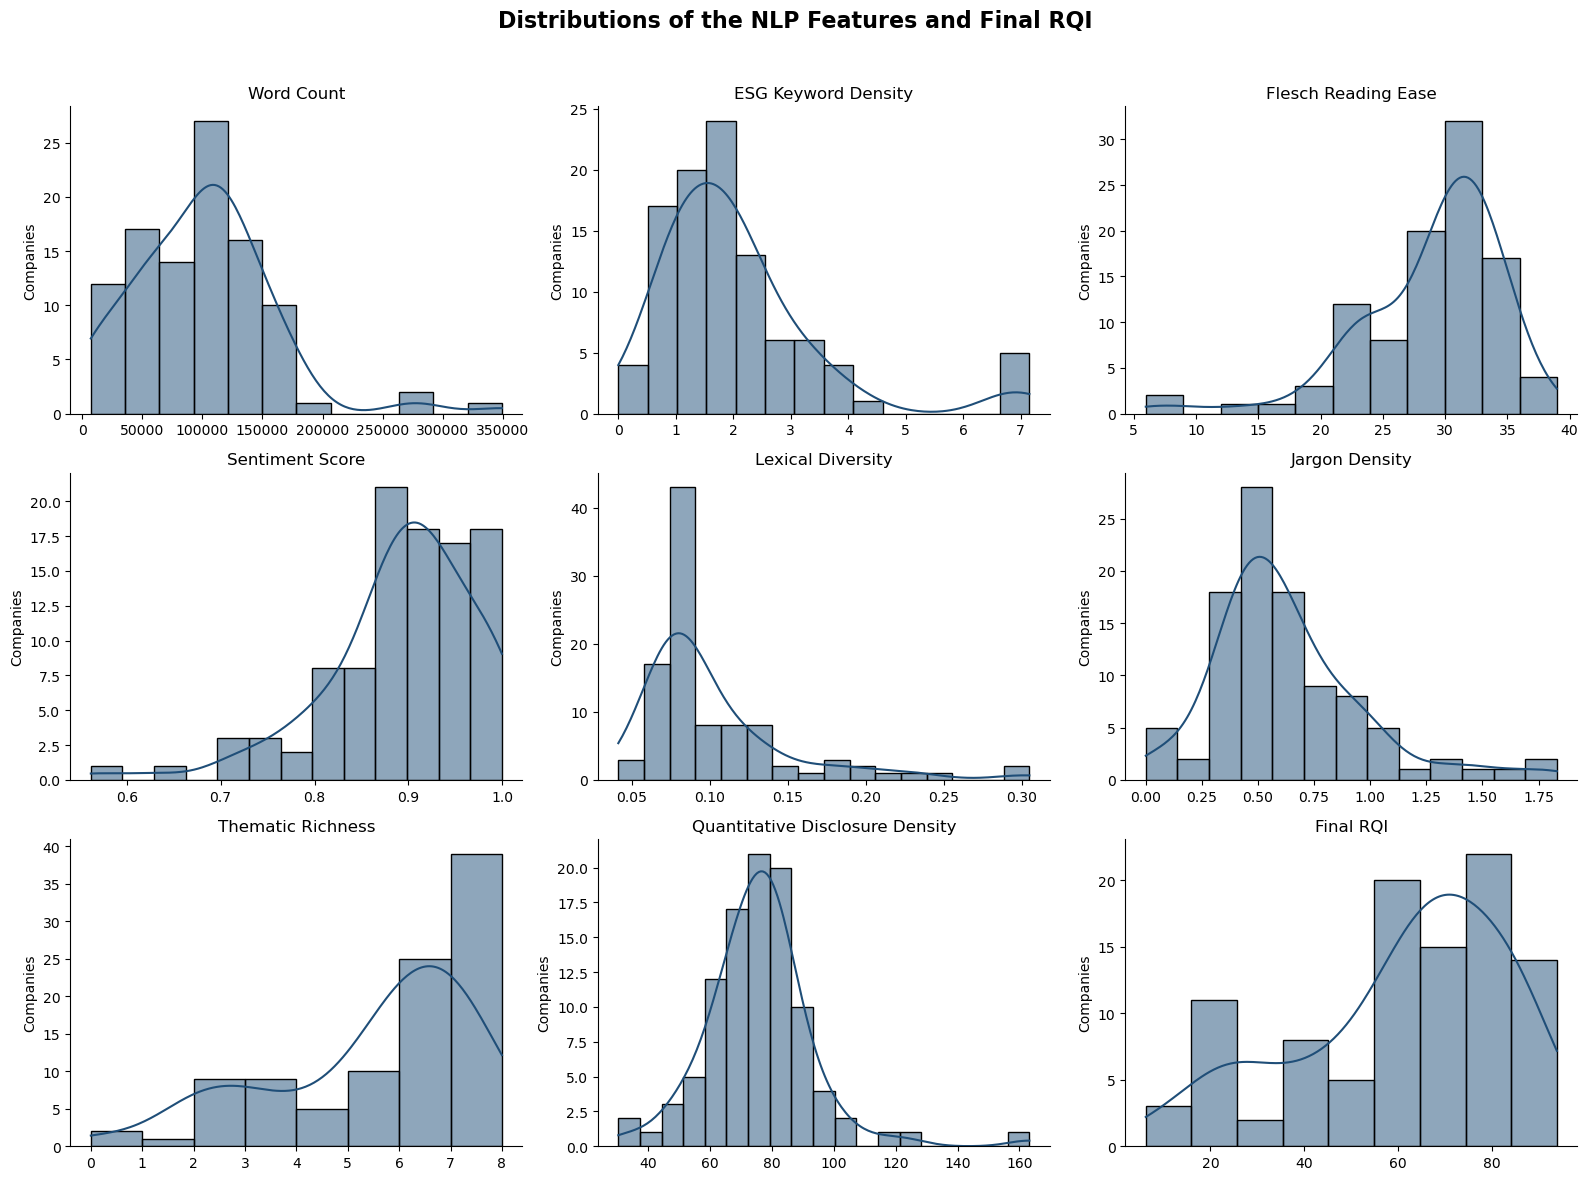

Chart saved as: Notebook04_Analytical_Variable_Distributions.png


In [4]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(16, 12)
)

axes = axes.flatten()

for axis, variable in zip(axes, analytical_variables):
    sns.histplot(
        data=analysis_df,
        x=variable,
        kde=True,
        color=PROJECT_COLOUR,
        ax=axis
    )

    axis.set_title(variable)
    axis.set_xlabel("")
    axis.set_ylabel("Companies")
    axis.spines[["top", "right"]].set_visible(False)

plt.suptitle(
    "Distributions of the NLP Features and Final RQI",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

distribution_chart = (
    OUTPUT_FOLDER
    / "Notebook04_Analytical_Variable_Distributions.png"
)

plt.savefig(
    distribution_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved as: {distribution_chart.name}")

### Statistical Interpretation of the Variable Distributions

The distributions indicate that several variables depart from a symmetrical bell-shaped pattern. Word Count is positively skewed, with most reports containing fewer than approximately 170,000 words and a small number extending beyond 250,000 words. ESG Keyword Density and Jargon Density are also positively skewed, indicating that most companies use these terms at relatively moderate levels while a smaller group uses them much more intensively. Lexical Diversity shows a similar right-skewed pattern, although this measure may be influenced by report length because longer documents naturally repeat more words.

Flesch Reading Ease is concentrated mainly between approximately 25 and 35, with a small number of considerably lower scores. This suggests that most reports are difficult to read and are written for readers with advanced knowledge. Sentiment Score is concentrated towards the positive end of its range, demonstrating the predominantly positive tone of corporate reporting, while the lower tail identifies a small number of comparatively neutral reports. Thematic Richness is concentrated between six and eight themes, indicating that most companies discuss several sustainability areas, although a smaller group provides much narrower thematic coverage. Quantitative Disclosure Density is relatively more symmetrical around approximately 70–90 numerical references per 1,000 words, but some extreme observations remain visible.

Final RQI is concentrated mainly between approximately 60 and 90, while a smaller group records substantially lower scores. Its stepped and potentially multimodal distribution reflects the construction of the index from eight discrete criterion scores rather than a continuously measured variable. Overall, the visual evidence suggests non-normality, skewness and potential outliers in several variables. These observations are preliminary and are assessed formally using the Shapiro–Wilk normality test and the interquartile-range outlier method in the subsequent sections.


## 5. Assess Normality Using the Shapiro–Wilk Test

The Shapiro–Wilk test is applied to the eight NLP features and Final RQI. A p-value below 0.05 indicates that the observed distribution differs significantly from a normal distribution.

In [5]:
from scipy.stats import shapiro

normality_results = []

for variable in analytical_variables:
    statistic, p_value = shapiro(
        analysis_df[variable].dropna()
    )

    normality_results.append({
        "Variable": variable,
        "Shapiro-Wilk Statistic": statistic,
        "P-Value": p_value,
        "Normally Distributed": (
            "Yes" if p_value >= 0.05 else "No"
        )
    })

normality_results = pd.DataFrame(normality_results)

normality_results.to_excel(
    DATA_FOLDER / "Notebook04_Normality_Test_Results.xlsx",
    index=False
)

display(
    normality_results.round(4).style.hide(axis="index")
)

variables_failing_normality = (
    normality_results["Normally Distributed"]
    .eq("No")
    .sum()
)

print(
    f"Variables failing normality: "
    f"{variables_failing_normality}"
)

Variable,Shapiro-Wilk Statistic,P-Value,Normally Distributed
Word Count,0.921100,0.000000,No
ESG Keyword Density,0.804200,0.000000,No
Flesch Reading Ease,0.893700,0.000000,No
Sentiment Score,0.909800,0.000000,No
Lexical Diversity,0.748300,0.000000,No
Jargon Density,0.906100,0.000000,No
Thematic Richness,0.878900,0.000000,No
Quantitative Disclosure Density,0.909300,0.000000,No
Final RQI,0.916300,0.000000,No


Variables failing normality: 9


### Statistical Interpretation of the Shapiro–Wilk Test

The Shapiro–Wilk results show that all eight NLP features and Final RQI have p-values below the 0.05 significance level. The null hypothesis of normality is therefore rejected for all nine analytical variables. The displayed p-values of 0.0000 are rounded values and should be reported as \(p < 0.001\), rather than interpreted as exactly zero. Lexical Diversity records the lowest Shapiro–Wilk statistic (\(W = 0.7483\)), followed by ESG Keyword Density (\(W = 0.8042\)), indicating the strongest departures from normality. Word Count (\(W = 0.9211\)) and Final RQI (\(W = 0.9163\)) are closer to normality but still differ significantly from a normal distribution.

These findings support the use of non-parametric statistical methods. Spearman’s rank correlation is therefore used to examine relationships between the NLP features and Final RQI, while the Kruskal–Wallis test is used to assess sector-based differences. The results do not automatically require the removal of observations or prevent predictive modelling, because Multiple Linear Regression primarily assumes that its residuals—not the individual predictors—are approximately normal. Random Forest and XGBoost also do not require normally distributed predictors.

## 6. Assess Potential Outliers

Potential outliers are identified using the interquartile-range method. Values below \(Q1 - 1.5 \times IQR\) or above \(Q3 + 1.5 \times IQR\) are flagged for assessment. The observations are not removed automatically because they may represent genuine differences in corporate-reporting practices.


In [6]:
outlier_results = []
outlier_flags = pd.DataFrame(index=analysis_df.index)

for variable in analytical_variables:
    q1 = analysis_df[variable].quantile(0.25)
    q3 = analysis_df[variable].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - (1.5 * iqr)
    upper_limit = q3 + (1.5 * iqr)

    flags = (
        analysis_df[variable].lt(lower_limit)
        | analysis_df[variable].gt(upper_limit)
    )

    outlier_flags[variable] = flags

    outlier_results.append({
        "Variable": variable,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outliers": flags.sum(),
        "Outlier Percentage": flags.mean() * 100
    })

outlier_results = pd.DataFrame(outlier_results)

outlier_results.to_excel(
    DATA_FOLDER / "Notebook04_Outlier_Assessment.xlsx",
    index=False
)

display(
    outlier_results.round(4).style.hide(axis="index")
)

print(
    "Total variable-level outlier flags:",
    int(outlier_flags.sum().sum())
)

Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Outliers,Outlier Percentage
Word Count,58310.500000,129411.500000,71101.000000,-48341.000000,236063.000000,3,3.000000
ESG Keyword Density,1.158200,2.411700,1.253500,-0.722200,4.292000,6,6.000000
Flesch Reading Ease,25.530400,32.592200,7.061800,14.937800,43.184800,3,3.000000
Sentiment Score,0.862400,0.943500,0.081100,0.740800,1.065100,5,5.000000
Lexical Diversity,0.076400,0.115000,0.038600,0.018600,0.172800,10,10.000000
Jargon Density,0.423900,0.763000,0.339000,-0.084700,1.271500,6,6.000000
Thematic Richness,4.000000,7.000000,3.000000,-0.500000,11.500000,0,0.000000
Quantitative Disclosure Density,66.199600,82.804200,16.604500,41.292900,107.710900,5,5.000000
Final RQI,50.000000,75.000000,25.000000,12.500000,112.500000,2,2.000000


Total variable-level outlier flags: 40


### Statistical Interpretation of the Outlier Assessment

The interquartile-range assessment identifies 40 variable-level outlier flags across the nine analytical variables. This does not necessarily represent 40 different companies because a single company may be flagged for more than one variable. Lexical Diversity records the highest number of potential outliers, with 10 companies (10%), followed by ESG Keyword Density and Jargon Density with six companies each (6%). Sentiment Score and Quantitative Disclosure Density each contain five potential outliers (5%), while Word Count and Flesch Reading Ease each contain three (3%). Final RQI contains only two potential outliers (2%), and no outliers are identified for Thematic Richness.

The flagged observations are retained because they may reflect genuine differences in report length, language, readability and disclosure practices rather than data-entry or processing errors. Their relatively low percentages also do not justify automatic removal, particularly with a sample of 100 companies. Spearman correlation, Kruskal–Wallis testing, Random Forest and XGBoost are comparatively robust to non-normality and extreme observations. The potential influence of these observations on Multiple Linear Regression is assessed through the model’s testing performance and residual diagnostics rather than through arbitrary deletion.

## 7. Examine Relationships Between the NLP Features and Final RQI

Spearman’s rank correlation is used because the analytical variables are not normally distributed. The analysis measures the direction and strength of the monotonic relationship between each NLP feature and Final RQI. The Benjamini–Hochberg procedure is applied to control the false-discovery rate across the eight tests.

In [7]:
from scipy.stats import spearmanr

def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    number_of_tests = len(p_values)
    order = np.argsort(p_values)
    ranked_p_values = p_values[order]

    adjusted_ranked = (
        ranked_p_values
        * number_of_tests
        / np.arange(1, number_of_tests + 1)
    )

    adjusted_ranked = np.minimum.accumulate(
        adjusted_ranked[::-1]
    )[::-1]

    adjusted_p_values = np.empty(number_of_tests)
    adjusted_p_values[order] = np.clip(
        adjusted_ranked,
        0,
        1
    )

    return adjusted_p_values

correlation_records = []

for feature in nlp_features:
    coefficient, p_value = spearmanr(
        analysis_df[feature],
        analysis_df[target_variable]
    )

    correlation_records.append({
        "NLP Feature": feature,
        "Spearman Coefficient": coefficient,
        "P-Value": p_value
    })

spearman_results = pd.DataFrame(correlation_records)

spearman_results["Adjusted P-Value"] = (
    benjamini_hochberg(spearman_results["P-Value"])
)

spearman_results["Statistically Significant"] = np.where(
    spearman_results["Adjusted P-Value"] < 0.05,
    "Yes",
    "No"
)

spearman_results = (
    spearman_results
    .sort_values("Spearman Coefficient", ascending=False)
    .reset_index(drop=True)
)

spearman_results.to_excel(
    DATA_FOLDER / "Notebook04_Spearman_Correlation_Results.xlsx",
    index=False
)

display(
    spearman_results.round(4).style.hide(axis="index")
)

print(
    "Significant relationships after adjustment:",
    spearman_results["Statistically Significant"].eq("Yes").sum()
)

NLP Feature,Spearman Coefficient,P-Value,Adjusted P-Value,Statistically Significant
Word Count,0.769600,0.000000,0.000000,Yes
Thematic Richness,0.752800,0.000000,0.000000,Yes
ESG Keyword Density,0.423600,0.000000,0.000000,Yes
Jargon Density,0.383000,0.000100,0.000100,Yes
Quantitative Disclosure Density,-0.015400,0.879400,0.879400,No
Flesch Reading Ease,-0.127500,0.206100,0.235500,No
Sentiment Score,-0.167400,0.096000,0.128000,No
Lexical Diversity,-0.694500,0.000000,0.000000,Yes


Significant relationships after adjustment: 5


### Statistical Interpretation of the Spearman Correlation Results

The p-values displayed as 0.000000 are extremely small values that become zero only after numerical rounding. They do not mean that the probability is exactly zero and should therefore be reported as \(p < 0.001\). The Benjamini–Hochberg adjustment controls the false-discovery rate across the eight simultaneous correlation tests. Five relationships remain statistically significant after this adjustment, indicating that these findings are unlikely to result from multiple-testing error.

Word Count (\(r_s = 0.770,\ p < 0.001\)) and Thematic Richness (\(r_s = 0.753,\ p < 0.001\)) show strong positive relationships with Final RQI. ESG Keyword Density shows a moderate positive relationship (\(r_s = 0.424,\ p < 0.001\)), while Jargon Density shows a weaker positive relationship (\(r_s = 0.383,\ p < 0.001\)). Lexical Diversity has a strong negative relationship with Final RQI (\(r_s = -0.695,\ p < 0.001\)). This negative result may partly reflect the effect of report length on the type–token ratio, because longer reports naturally contain more repeated vocabulary.

Quantitative Disclosure Density, Flesch Reading Ease and Sentiment Score do not show statistically significant relationships with Final RQI after adjustment. Their observed coefficients are therefore insufficient to conclude that they have consistent monotonic relationships with reporting quality in this sample. The results indicate association rather than causation, and the strong relationships involving report length and thematic coverage should be interpreted alongside the predictor-correlation and multicollinearity assessments.

## 8. Visualise the Spearman Correlation Results

The Spearman coefficients are presented in a vertical bar chart. Statistically significant relationships are shown in dark blue, while non-significant relationships are shown in light blue.


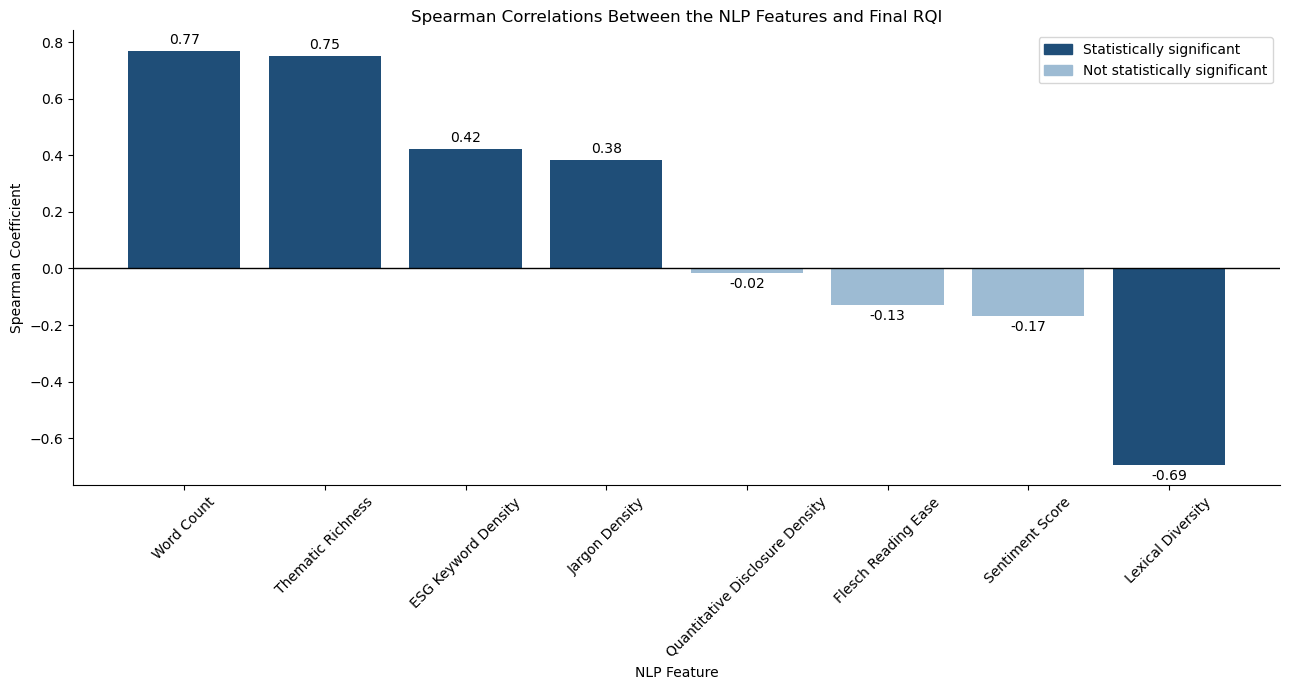

Chart saved as: Notebook04_Spearman_Correlations_with_Final_RQI.png


In [8]:
significant_colour = PROJECT_COLOUR
non_significant_colour = "#9DBBD3"

bar_colours = np.where(
    spearman_results["Statistically Significant"].eq("Yes"),
    significant_colour,
    non_significant_colour
)

fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    spearman_results["NLP Feature"],
    spearman_results["Spearman Coefficient"],
    color=bar_colours
)

ax.axhline(0, color="black", linewidth=1)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value in spearman_results["Spearman Coefficient"]
    ],
    padding=3,
    fontsize=10
)

ax.set_title(
    "Spearman Correlations Between the NLP Features and Final RQI"
)
ax.set_xlabel("NLP Feature")
ax.set_ylabel("Spearman Coefficient")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch

ax.legend(
    handles=[
        Patch(
            color=significant_colour,
            label="Statistically significant"
        ),
        Patch(
            color=non_significant_colour,
            label="Not statistically significant"
        )
    ]
)

plt.tight_layout()

correlation_chart = (
    OUTPUT_FOLDER
    / "Notebook04_Spearman_Correlations_with_Final_RQI.png"
)

plt.savefig(
    correlation_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved as: {correlation_chart.name}")

### Interpretation of the Spearman Correlation Chart

The chart shows that Word Count and Thematic Richness have the strongest positive relationships with Final RQI, with coefficients of approximately 0.77 and 0.75 respectively. ESG Keyword Density and Jargon Density also have statistically significant positive relationships, although their coefficients of approximately 0.42 and 0.38 indicate more moderate associations. These results suggest that longer reports, broader thematic coverage and more intensive use of ESG-related and specialist terminology are generally associated with higher reporting-quality scores.

Lexical Diversity shows a strong and statistically significant negative relationship with Final RQI of approximately −0.69. This result may partly arise because longer reports contain more repeated terminology, which reduces the type–token ratio used to measure lexical diversity. Quantitative Disclosure Density, Flesch Reading Ease and Sentiment Score have weak coefficients and are not statistically significant. The chart therefore distinguishes the features showing meaningful monotonic relationships from those for which the sample provides insufficient statistical evidence.

## 9. Examine Correlations Among the NLP Predictors

Spearman correlations among the eight NLP features are examined to identify strongly related predictors before multicollinearity testing. Absolute coefficients of 0.70 or above are flagged as strong relationships.

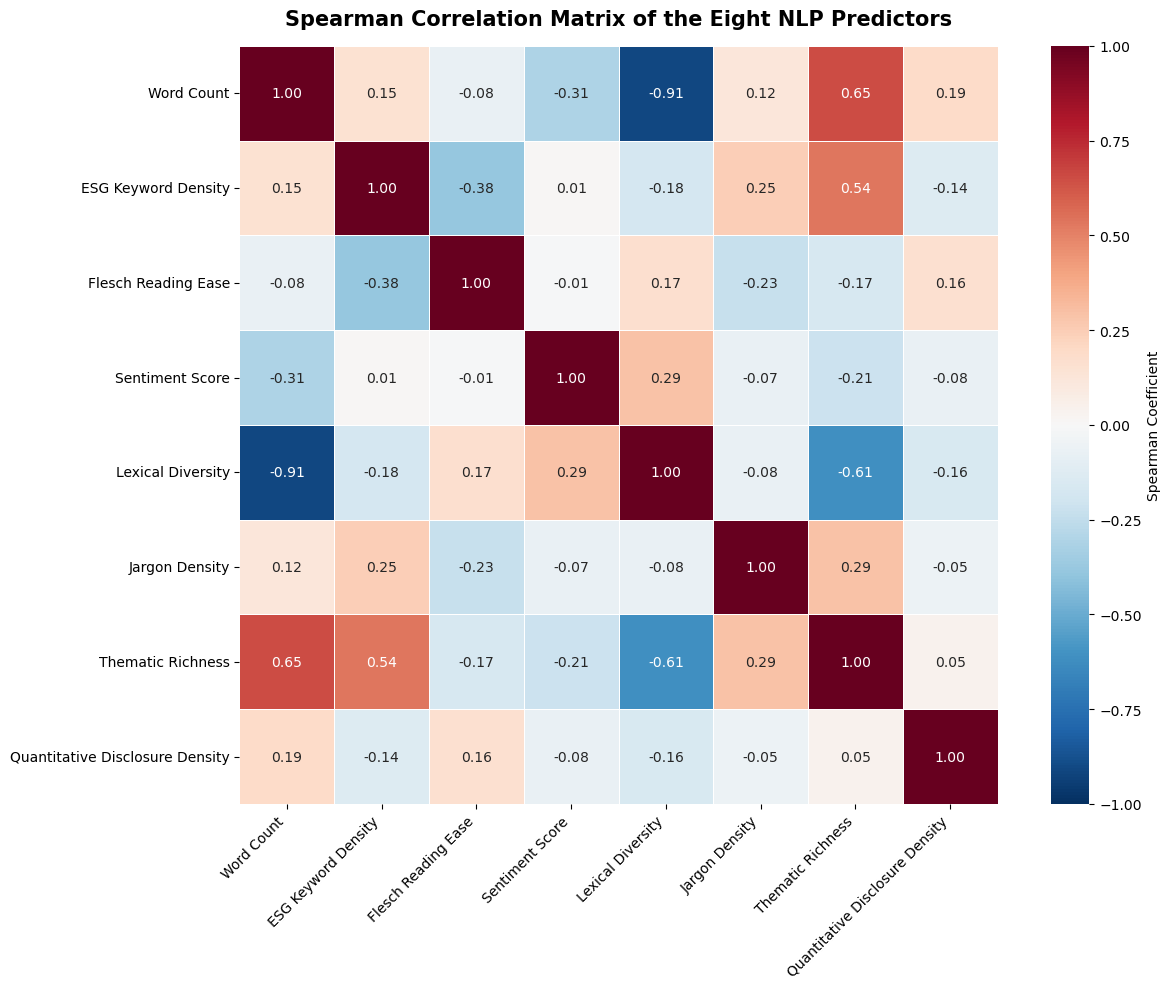

STRONG PREDICTOR RELATIONSHIPS
----------------------------------------
 Feature 1         Feature 2  Spearman Coefficient
Word Count Lexical Diversity               -0.9111

Chart saved as: Notebook04_NLP_Predictor_Correlation_Matrix.png


In [10]:
predictor_correlation_matrix = (
    analysis_df[nlp_features].corr(method="spearman")
)

strong_relationships = []

for first_position, first_feature in enumerate(nlp_features):
    for second_feature in nlp_features[first_position + 1:]:
        coefficient = predictor_correlation_matrix.loc[
            first_feature,
            second_feature
        ]

        if abs(coefficient) >= 0.70:
            strong_relationships.append({
                "Feature 1": first_feature,
                "Feature 2": second_feature,
                "Spearman Coefficient": coefficient
            })

strong_predictor_relationships = pd.DataFrame(
    strong_relationships
)

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    predictor_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman Coefficient"},
    ax=ax
)

ax.set_title(
    "Spearman Correlation Matrix of the Eight NLP Predictors",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
)

plt.tight_layout()

matrix_chart = (
    OUTPUT_FOLDER
    / "Notebook04_NLP_Predictor_Correlation_Matrix.png"
)

plt.savefig(
    matrix_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("STRONG PREDICTOR RELATIONSHIPS")
print("-" * 40)

if strong_predictor_relationships.empty:
    print("No predictor pairs have an absolute correlation of 0.70 or above.")
else:
    print(
        strong_predictor_relationships
        .round(4)
        .to_string(index=False)
    )

with pd.ExcelWriter(
    DATA_FOLDER / "Notebook04_Predictor_Correlations.xlsx",
    engine="openpyxl"
) as writer:
    predictor_correlation_matrix.to_excel(
        writer,
        sheet_name="Correlation Matrix"
    )
    strong_predictor_relationships.to_excel(
        writer,
        sheet_name="Strong Relationships",
        index=False
    )

print(f"\nChart saved as: {matrix_chart.name}")

### Statistical Interpretation of the Predictor Correlation Matrix

The heatmap shows that most relationships among the eight NLP predictors are weak or moderate, suggesting that the variables generally measure different textual characteristics. The strongest relationship is between Word Count and Lexical Diversity (\(r_s=-0.91\)). This strong negative association indicates that longer reports tend to have lower type–token ratios because vocabulary is repeated more frequently as document length increases. The result therefore reflects a known sensitivity of lexical-diversity measures to document length and indicates possible redundancy between these two predictors.

Other notable relationships include Word Count and Thematic Richness (\(r_s=0.65\)), Lexical Diversity and Thematic Richness (\(r_s=-0.61\)), and ESG Keyword Density and Thematic Richness (\(r_s=0.54\)). These coefficients are moderate to moderately strong but remain below the predefined threshold of 0.70. The diagonal values of 1.00 only represent each variable’s perfect correlation with itself. Overall, the Word Count–Lexical Diversity relationship presents the main potential multicollinearity concern. Variance Inflation Factor analysis is therefore required before the Multiple Linear Regression model is interpreted. Any resulting multicollinearity is more important for regression coefficients than for Random Forest or XGBoost predictions.

## 10. Assess Multicollinearity Using the Variance Inflation Factor

The Variance Inflation Factor is calculated for the eight numerical NLP predictors. A VIF below 5 is treated as acceptable, a value from 5 to 10 indicates potential concern, and a value above 10 indicates serious multicollinearity.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def calculate_vif(dataframe):
    vif_records = []

    for feature in dataframe.columns:
        other_features = [
            column for column in dataframe.columns
            if column != feature
        ]

        model = LinearRegression()
        model.fit(
            dataframe[other_features],
            dataframe[feature]
        )

        predicted_values = model.predict(
            dataframe[other_features]
        )

        r_squared = r2_score(
            dataframe[feature],
            predicted_values
        )

        vif = (
            np.inf if r_squared >= 1
            else 1 / (1 - r_squared)
        )

        if vif > 10:
            assessment = "Serious Concern"
        elif vif >= 5:
            assessment = "Potential Concern"
        else:
            assessment = "Acceptable"

        vif_records.append({
            "NLP Feature": feature,
            "VIF": vif,
            "Assessment": assessment
        })

    return (
        pd.DataFrame(vif_records)
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )

vif_results = calculate_vif(
    analysis_df[nlp_features]
)

vif_results.to_excel(
    DATA_FOLDER / "Notebook04_VIF_Results.xlsx",
    index=False
)

print(
    vif_results
    .round({"VIF": 4})
    .to_string(index=False)
)

print(
    "\nFeatures with VIF of at least 5:",
    vif_results["VIF"].ge(5).sum()
)

                    NLP Feature    VIF Assessment
              Lexical Diversity 3.4860 Acceptable
                     Word Count 3.0911 Acceptable
              Thematic Richness 3.0687 Acceptable
            ESG Keyword Density 1.9746 Acceptable
            Flesch Reading Ease 1.4259 Acceptable
                 Jargon Density 1.2700 Acceptable
Quantitative Disclosure Density 1.1950 Acceptable
                Sentiment Score 1.1394 Acceptable

Features with VIF of at least 5: 0


## 11. Assess Sector-Based Differences in Final RQI

Final RQI is summarised across the TRBC sectors and compared using the Kruskal–Wallis test. This non-parametric test is appropriate because Final RQI is not normally distributed. Epsilon-squared is also calculated to estimate the strength of the sector effect.

In [13]:
from scipy.stats import kruskal

sector_statistics = (
    analysis_df.groupby(control_variable)[target_variable]
    .agg(
        Companies="count",
        Mean="mean",
        Median="median",
        Standard_Deviation="std",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

sector_groups = [
    group[target_variable].values
    for _, group in analysis_df.groupby(control_variable)
]

kruskal_h, kruskal_p = kruskal(*sector_groups)

number_of_sectors = analysis_df[control_variable].nunique()
sample_size = len(analysis_df)

epsilon_squared = max(
    0,
    (
        kruskal_h - number_of_sectors + 1
    ) / (
        sample_size - number_of_sectors
    )
)

sector_test_results = pd.DataFrame({
    "Kruskal-Wallis H": [kruskal_h],
    "P-Value": [kruskal_p],
    "Epsilon Squared": [epsilon_squared],
    "Statistically Significant": [
        "Yes" if kruskal_p < 0.05 else "No"
    ]
})

with pd.ExcelWriter(
    DATA_FOLDER / "Notebook04_Sector_Based_RQI_Analysis.xlsx",
    engine="openpyxl"
) as writer:
    sector_statistics.to_excel(
        writer,
        sheet_name="Sector Statistics",
        index=False
    )
    sector_test_results.to_excel(
        writer,
        sheet_name="Kruskal Wallis Test",
        index=False
    )

print("SECTOR DESCRIPTIVE STATISTICS")
print("-" * 35)
print(
    sector_statistics
    .round(4)
    .to_string(index=False)
)

print("\nKRUSKAL–WALLIS TEST")
print("-" * 35)
print(
    sector_test_results
    .round(4)
    .to_string(index=False)
)

SECTOR DESCRIPTIVE STATISTICS
-----------------------------------
           TRBC Sector  Companies    Mean  Median  Standard_Deviation  Minimum  Maximum
       Basic Materials          6 71.8750  68.750             11.0043    62.50    87.50
    Consumer Cyclicals         16 71.4844  68.750             16.6096    25.00    87.50
Consumer Non-Cyclicals          5 80.0000  81.250              8.1490    68.75    87.50
                Energy          3 75.0000  81.250             16.5359    56.25    87.50
            Financials         38 45.3947  43.750             21.5864     6.25    87.50
            Healthcare          2 71.8750  71.875              4.4194    68.75    75.00
           Industrials         14 71.4286  75.000             19.2582    18.75    93.75
           Real Estate          8 59.3750  62.500             21.9069    12.50    87.50
            Technology          6 67.7083  65.625             11.4678    56.25    81.25
             Utilities          2 71.8750  71.875     

### Statistical Interpretation of the Sector-Based Analysis

The descriptive results show substantial differences in Final RQI across the TRBC sectors. Consumer Non-Cyclicals records the highest mean Final RQI of 80.00, followed by Energy at 75.00. Financials records the lowest mean of 45.39 and median of 43.75, while Real Estate also has a comparatively lower mean of 59.38. Financials contains the largest number of companies and shows considerable variation, with scores ranging from 6.25 to 87.50. However, the sector means for Energy, Healthcare and Utilities should be interpreted cautiously because these groups contain only two or three companies.

The Kruskal–Wallis test confirms that Final RQI differs significantly across the sectors, \(H(9)=35.17,\ p<0.001\). The epsilon-squared value of 0.291 indicates a large sector effect, suggesting that sector membership explains a meaningful proportion of the variation in ranked reporting-quality scores. However, the Kruskal–Wallis test is an omnibus test: it demonstrates that at least one sector differs but does not identify the specific sector pairs responsible for the result. The unequal and sometimes very small sector samples also limit sector-level generalisation. TRBC Sector is therefore retained as a control variable in the predictive models.

## 12. Prepare the Training and Testing Samples

The eight NLP features and TRBC Sector are prepared as model predictors, while Final RQI is retained as the dependent variable. The dataset is divided into 80% training data and 20% testing data using the fixed random seed of 42. Sector-stratified splitting is applied to preserve sector representation where possible.

In [14]:
from sklearn.model_selection import train_test_split

model_features = nlp_features + [control_variable]

X = analysis_df[model_features].copy()
y = analysis_df[target_variable].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=analysis_df[control_variable]
)

split_summary = pd.DataFrame({
    "Sample": ["Training Sample", "Testing Sample", "Total"],
    "Companies": [
        len(X_train),
        len(X_test),
        len(X)
    ],
    "Percentage": [
        len(X_train) / len(X) * 100,
        len(X_test) / len(X) * 100,
        100.0
    ]
})

print(
    split_summary
    .round(1)
    .to_string(index=False)
)

print("\nTraining-sector distribution:")
print(
    X_train[control_variable]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nTesting-sector distribution:")
print(
    X_test[control_variable]
    .value_counts()
    .sort_index()
    .to_string()
)

         Sample  Companies  Percentage
Training Sample         80        80.0
 Testing Sample         20        20.0
          Total        100       100.0

Training-sector distribution:
TRBC Sector
Basic Materials            5
Consumer Cyclicals        13
Consumer Non-Cyclicals     4
Energy                     2
Financials                30
Healthcare                 2
Industrials               11
Real Estate                6
Technology                 5
Utilities                  2

Testing-sector distribution:
TRBC Sector
Basic Materials           1
Consumer Cyclicals        3
Consumer Non-Cyclicals    1
Energy                    1
Financials                8
Industrials               3
Real Estate               2
Technology                1


## 13. Develop the Multiple Linear Regression Baseline Model

Multiple Linear Regression is developed as the baseline predictive model. The numerical NLP features are standardised, while TRBC Sector is converted into dummy variables. Model performance is assessed using the training sample, unseen testing sample and five-fold cross-validation.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R-Squared": r2_score(actual, predicted)
    }

model_preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        nlp_features
    ),
    (
        "sector",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ),
        [control_variable]
    )
])

mlr_model = Pipeline([
    ("preprocessor", model_preprocessor),
    ("model", LinearRegression())
])

five_fold_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

mlr_cv_predictions = cross_val_predict(
    mlr_model,
    X_train,
    y_train,
    cv=five_fold_cv,
    n_jobs=-1
)

mlr_model.fit(X_train, y_train)

mlr_train_predictions = mlr_model.predict(X_train)
mlr_test_predictions = mlr_model.predict(X_test)

mlr_performance = pd.DataFrame([
    {
        "Evaluation": "Training Sample",
        **regression_metrics(
            y_train,
            mlr_train_predictions
        )
    },
    {
        "Evaluation": "Testing Sample",
        **regression_metrics(
            y_test,
            mlr_test_predictions
        )
    },
    {
        "Evaluation": "Five-Fold CV",
        **regression_metrics(
            y_train,
            mlr_cv_predictions
        )
    }
])

mlr_performance.to_excel(
    DATA_FOLDER / "Notebook04_MLR_Performance.xlsx",
    index=False
)

print(
    mlr_performance
    .round(4)
    .to_string(index=False)
)

     Evaluation     MAE    RMSE  R-Squared
Training Sample  6.9383  8.5959     0.8410
 Testing Sample 10.2595 12.4232     0.6944
   Five-Fold CV  9.6531 12.0177     0.6893


### Statistical Interpretation of the Multiple Linear Regression Model

The Multiple Linear Regression model explains 84.1% of the variation in Final RQI within the training sample (\(R^2=0.841\)). Its training MAE of 6.94 indicates that predictions differ from the observed RQI scores by approximately seven points on average, while the RMSE of 8.60 shows that some predictions have larger errors. The lower testing \(R^2\) of 0.694 indicates that the model explains approximately 69.4% of the variation in Final RQI for the unseen companies. The testing MAE of 10.26 and RMSE of 12.42 indicate an average prediction error of approximately ten RQI points, with greater penalties arising from a smaller number of larger errors.

The five-fold cross-validation results are close to the testing results, with an MAE of 9.65, RMSE of 12.02 and \(R^2\) of 0.689. This consistency suggests that the model provides reasonably stable predictive performance across different subsets of the data. The difference between training and testing performance indicates some model optimism, but it does not suggest severe overfitting. Multiple Linear Regression therefore provides a strong baseline against which the Random Forest and XGBoost models can be compared. However, its individual coefficients should still be interpreted cautiously where predictor multicollinearity is present.

## 14. Develop and Tune the Random Forest Model

A Random Forest regression model is developed to capture possible non-linear relationships and interactions among the NLP features. Grid search and five-fold cross-validation are used to select the best model settings based on RMSE.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_predict

tree_preprocessor = ColumnTransformer([
    (
        "numeric",
        "passthrough",
        nlp_features
    ),
    (
        "sector",
        OneHotEncoder(handle_unknown="ignore"),
        [control_variable]
    )
])

rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=SEED,
            n_jobs=-1
        )
    )
])

rf_parameters = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", 0.8]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_parameters,
    scoring="neg_root_mean_squared_error",
    cv=five_fold_cv,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_

rf_train_predictions = best_rf_model.predict(X_train)
rf_test_predictions = best_rf_model.predict(X_test)

rf_cv_predictions = cross_val_predict(
    best_rf_model,
    X_train,
    y_train,
    cv=five_fold_cv,
    n_jobs=-1
)

rf_performance = pd.DataFrame([
    {
        "Evaluation": "Training Sample",
        **regression_metrics(
            y_train,
            rf_train_predictions
        )
    },
    {
        "Evaluation": "Testing Sample",
        **regression_metrics(
            y_test,
            rf_test_predictions
        )
    },
    {
        "Evaluation": "Five-Fold CV",
        **regression_metrics(
            y_train,
            rf_cv_predictions
        )
    }
])

rf_parameter_results = pd.DataFrame(
    list(rf_search.best_params_.items()),
    columns=["Parameter", "Selected Value"]
)

with pd.ExcelWriter(
    DATA_FOLDER / "Notebook04_Random_Forest_Performance.xlsx",
    engine="openpyxl"
) as writer:
    rf_performance.to_excel(
        writer,
        sheet_name="Performance",
        index=False
    )
    rf_parameter_results.to_excel(
        writer,
        sheet_name="Best Parameters",
        index=False
    )

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nRandom Forest performance:")
print(
    rf_performance
    .round(4)
    .to_string(index=False)
)

Best Random Forest parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 400}

Random Forest performance:
     Evaluation    MAE    RMSE  R-Squared
Training Sample 5.0879  6.1921     0.9175
 Testing Sample 9.5515 12.4480     0.6932
   Five-Fold CV 9.1931 11.0459     0.7375


### Statistical Interpretation of the Random Forest Model

The selected Random Forest contains 400 decision trees, considers the square root of the available predictors at each split, allows the trees to grow without a fixed maximum depth and requires at least two observations in each terminal leaf. The large number of trees improves prediction stability, while the use of a predictor subset and a minimum leaf size of two helps reduce excessive model complexity.

The model explains 91.8% of the variation in Final RQI within the training sample, with an MAE of 5.09 and RMSE of 6.19. Performance decreases on the unseen testing sample to an \(R^2\) of 0.693, an MAE of 9.55 and an RMSE of 12.45. This training–testing difference indicates some overfitting, although the five-fold cross-validation results remain strong, with an \(R^2\) of 0.738, MAE of 9.19 and RMSE of 11.05. The close testing and cross-validation results suggest that the model retains reasonable predictive stability.

Compared with Multiple Linear Regression, Random Forest produces a lower testing MAE and stronger cross-validation performance, but its testing RMSE and \(R^2\) are very similar. Random Forest therefore shows an improvement in average prediction accuracy and cross-validation stability, but the final model choice should be based on the complete comparison with XGBoost rather than the training performance alone.

## 15. Develop and Tune the XGBoost Model

An XGBoost regression model is developed to capture complex non-linear relationships while controlling model errors through sequential boosting. Grid search and five-fold cross-validation are used to select the best learning rate, tree depth, number of trees and sampling proportion.

In [19]:
%pip install -q xgboost

from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    (
        "model",
        XGBRegressor(
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=1,
            colsample_bytree=0.8,
            verbosity=0
        )
    )
])

xgb_parameters = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [2, 3],
    "model__learning_rate": [0.05, 0.10],
    "model__subsample": [0.8, 1.0]
}

xgb_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_parameters,
    scoring="neg_root_mean_squared_error",
    cv=five_fold_cv,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb_model = xgb_search.best_estimator_

xgb_train_predictions = best_xgb_model.predict(X_train)
xgb_test_predictions = best_xgb_model.predict(X_test)

xgb_cv_predictions = cross_val_predict(
    best_xgb_model,
    X_train,
    y_train,
    cv=five_fold_cv,
    n_jobs=-1
)

xgb_performance = pd.DataFrame([
    {
        "Evaluation": "Training Sample",
        **regression_metrics(
            y_train,
            xgb_train_predictions
        )
    },
    {
        "Evaluation": "Testing Sample",
        **regression_metrics(
            y_test,
            xgb_test_predictions
        )
    },
    {
        "Evaluation": "Five-Fold CV",
        **regression_metrics(
            y_train,
            xgb_cv_predictions
        )
    }
])

xgb_parameter_results = pd.DataFrame(
    list(xgb_search.best_params_.items()),
    columns=["Parameter", "Selected Value"]
)

with pd.ExcelWriter(
    DATA_FOLDER / "Notebook04_XGBoost_Performance.xlsx",
    engine="openpyxl"
) as writer:
    xgb_performance.to_excel(
        writer,
        sheet_name="Performance",
        index=False
    )
    xgb_parameter_results.to_excel(
        writer,
        sheet_name="Best Parameters",
        index=False
    )

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nXGBoost performance:")
print(
    xgb_performance
    .round(4)
    .to_string(index=False)
)

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.4.6 which is incompatible.
streamlit 1.45.1 requires pandas<3,>=1.4.0, but you have pandas 3.0.5 which is incompatible.


Note: you may need to restart the kernel to use updated packages.
Best XGBoost parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}

XGBoost performance:
     Evaluation    MAE    RMSE  R-Squared
Training Sample 4.6061  5.5905     0.9328
 Testing Sample 9.5914 12.5677     0.6872
   Five-Fold CV 9.6046 11.9935     0.6905


### Statistical Interpretation of the XGBoost Model

The selected XGBoost model uses a learning rate of 0.05, a maximum tree depth of two, 100 boosting trees and a subsampling proportion of 0.80. These relatively conservative settings restrict tree complexity and allow the model to learn gradually, while subsampling reduces dependence on individual training observations.

The model explains 93.3% of the variation in Final RQI within the training sample, with an MAE of 4.61 and RMSE of 5.59. On the unseen testing sample, performance decreases to an \(R^2\) of 0.687, MAE of 9.59 and RMSE of 12.57. The five-fold cross-validation results are similar to the testing results, with an \(R^2\) of 0.691, MAE of 9.60 and RMSE of 11.99. This consistency suggests stable out-of-sample performance, although the substantial difference between the training and validation results indicates moderate overfitting.

XGBoost does not produce a clear improvement over Random Forest or Multiple Linear Regression in this sample. Random Forest records stronger cross-validation performance, while Multiple Linear Regression records a slightly lower testing RMSE and slightly higher testing \(R^2\). The final model decision should therefore prioritise unseen-sample and cross-validation performance rather than XGBoost’s stronger training results.

## 16. Compare the Predictive Models

The testing and five-fold cross-validation results from Multiple Linear Regression, Random Forest and XGBoost are combined. Lower MAE and RMSE values indicate smaller prediction errors, while a higher R-squared value indicates stronger explanatory performance. Cross-validation RMSE is used as the principal model-selection measure because it evaluates performance across several data partitions.

In [20]:
model_performance_tables = {
    "Multiple Linear Regression": mlr_performance,
    "Random Forest": rf_performance,
    "XGBoost": xgb_performance
}

comparison_records = []

for model_name, performance_table in model_performance_tables.items():
    for evaluation in ["Testing Sample", "Five-Fold CV"]:
        result = performance_table.loc[
            performance_table["Evaluation"] == evaluation
        ].iloc[0]

        comparison_records.append({
            "Model": model_name,
            "Evaluation": evaluation,
            "MAE": result["MAE"],
            "RMSE": result["RMSE"],
            "R-Squared": result["R-Squared"]
        })

model_comparison = pd.DataFrame(comparison_records)

testing_results = model_comparison[
    model_comparison["Evaluation"] == "Testing Sample"
]

cv_results = model_comparison[
    model_comparison["Evaluation"] == "Five-Fold CV"
]

best_testing_model_name = (
    testing_results.loc[
        testing_results["RMSE"].idxmin(),
        "Model"
    ]
)

best_cv_model_name = (
    cv_results.loc[
        cv_results["RMSE"].idxmin(),
        "Model"
    ]
)

model_lookup = {
    "Multiple Linear Regression": mlr_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_xgb_model
}

final_model_name = best_cv_model_name
final_model = model_lookup[final_model_name]

model_comparison.to_excel(
    DATA_FOLDER / "Notebook04_Model_Performance_Comparison.xlsx",
    index=False
)

print(
    model_comparison
    .round(4)
    .to_string(index=False)
)

print(
    f"\nBest model based on testing RMSE: "
    f"{best_testing_model_name}"
)

print(
    f"Best model based on cross-validation RMSE: "
    f"{best_cv_model_name}"
)

print(
    f"Final model selected: {final_model_name}"
)

                     Model     Evaluation     MAE    RMSE  R-Squared
Multiple Linear Regression Testing Sample 10.2595 12.4232     0.6944
Multiple Linear Regression   Five-Fold CV  9.6531 12.0177     0.6893
             Random Forest Testing Sample  9.5515 12.4480     0.6932
             Random Forest   Five-Fold CV  9.1931 11.0459     0.7375
                   XGBoost Testing Sample  9.5914 12.5677     0.6872
                   XGBoost   Five-Fold CV  9.6046 11.9935     0.6905

Best model based on testing RMSE: Multiple Linear Regression
Best model based on cross-validation RMSE: Random Forest
Final model selected: Random Forest


### Statistical Interpretation of the Model Comparison

Multiple Linear Regression records the lowest testing RMSE of 12.42 and the highest testing \(R^2\) of 0.694. However, its advantage over Random Forest is extremely small: the Random Forest testing RMSE is 12.45 and its testing \(R^2\) is 0.693. Random Forest also produces a lower testing MAE of 9.55 compared with 10.26 for Multiple Linear Regression, indicating that its predictions have a smaller absolute error on average. XGBoost records similar testing performance but does not outperform the other models on any principal testing measure.

Random Forest produces the strongest five-fold cross-validation results, with the lowest MAE of 9.19, the lowest RMSE of 11.05 and the highest \(R^2\) of 0.738. These results are stronger than the cross-validation performance of both Multiple Linear Regression and XGBoost. Cross-validation is given greater weight because it evaluates performance across five different data partitions, whereas the testing results are based on only 20 companies and may be more sensitive to the particular observations included in that split.

Random Forest is therefore selected as the final predictive model. The selection reflects its stronger and more consistent cross-validation performance rather than its training accuracy. The very small testing RMSE difference between Random Forest and Multiple Linear Regression does not provide sufficient evidence that the linear model generalises better. Random Forest also has the methodological advantage of capturing non-linear relationships and interactions without requiring normally distributed predictors.

## 17. Visualise the Predictive Model Comparison

The testing and five-fold cross-validation performance of the three models is compared across MAE, RMSE and R-squared. This visualisation supports the selection of the model with the most consistent out-of-sample performance.

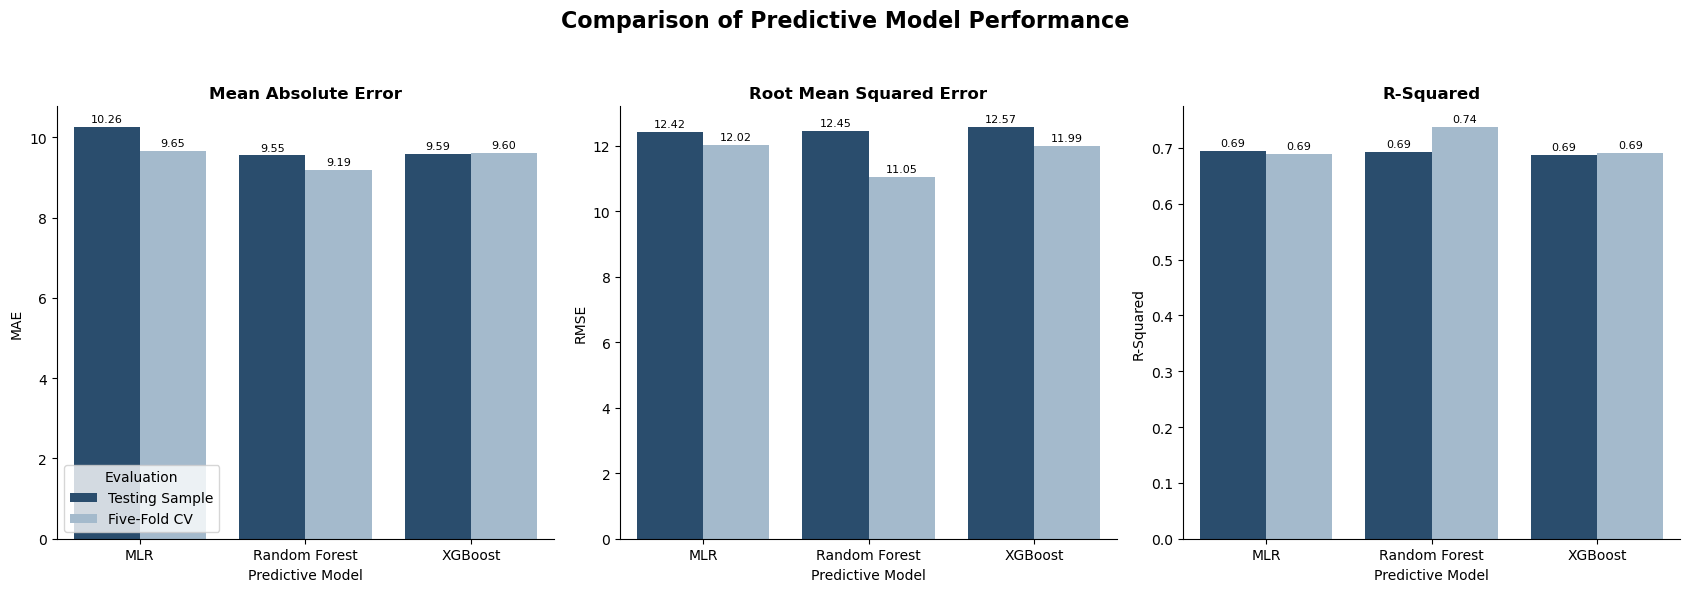

Chart saved as: Notebook04_Predictive_Model_Performance_Comparison.png


In [21]:
model_order = [
    "Multiple Linear Regression",
    "Random Forest",
    "XGBoost"
]

short_model_names = {
    "Multiple Linear Regression": "MLR",
    "Random Forest": "Random Forest",
    "XGBoost": "XGBoost"
}

plot_data = model_comparison.copy()
plot_data["Model"] = plot_data["Model"].map(
    short_model_names
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 6)
)

metrics = ["MAE", "RMSE", "R-Squared"]
titles = [
    "Mean Absolute Error",
    "Root Mean Squared Error",
    "R-Squared"
]

for axis, metric, title in zip(axes, metrics, titles):
    sns.barplot(
        data=plot_data,
        x="Model",
        y=metric,
        hue="Evaluation",
        palette={
            "Testing Sample": PROJECT_COLOUR,
            "Five-Fold CV": "#9DBBD3"
        },
        ax=axis
    )

    axis.set_title(title, fontweight="bold")
    axis.set_xlabel("Predictive Model")
    axis.set_ylabel(metric)
    axis.spines[["top", "right"]].set_visible(False)

    for container in axis.containers:
        axis.bar_label(
            container,
            fmt="%.2f",
            padding=2,
            fontsize=8
        )

axes[1].get_legend().remove()
axes[2].get_legend().remove()
axes[0].legend(title="Evaluation")

plt.suptitle(
    "Comparison of Predictive Model Performance",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

comparison_chart = (
    OUTPUT_FOLDER
    / "Notebook04_Predictive_Model_Performance_Comparison.png"
)

plt.savefig(
    comparison_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved as: {comparison_chart.name}")

### Interpretation of the Predictive Model Comparison Chart

The chart shows that the three models produce broadly similar results on the unseen testing sample. Multiple Linear Regression records the lowest testing RMSE of 12.42, while Random Forest records the lowest testing MAE of 9.55. The testing \(R^2\) values are approximately 0.69 for all three models, indicating that each model explains about 69% of the variation in Final RQI among the 20 testing companies. The small differences in testing performance do not demonstrate a clear practical advantage for any single model.

The cross-validation results provide stronger evidence in favour of Random Forest. It records the lowest cross-validation MAE of 9.19, the lowest RMSE of 11.05 and the highest \(R^2\) of 0.74. Multiple Linear Regression and XGBoost both produce cross-validation \(R^2\) values of approximately 0.69 and RMSE values close to 12.00. Random Forest is therefore selected because it demonstrates the most consistent performance across repeated data partitions, while still maintaining testing performance comparable to the other models.

## 18. Assess the Importance of the Eight NLP Features

Permutation importance is calculated using the unseen testing sample and the selected Random Forest model. Each feature is shuffled repeatedly, and the resulting increase in RMSE measures how much the model depends on that feature. TRBC Sector remains a control variable but is excluded from the NLP feature-importance table.

In [22]:
from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=SEED,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Increase in RMSE":
        permutation_results.importances_mean,
    "Standard Deviation":
        permutation_results.importances_std
})

nlp_feature_importance = (
    feature_importance[
        feature_importance["Feature"].isin(nlp_features)
    ]
    .sort_values(
        "Mean Increase in RMSE",
        ascending=False
    )
    .reset_index(drop=True)
)

nlp_feature_importance.to_excel(
    DATA_FOLDER
    / "Notebook04_Random_Forest_Feature_Importance.xlsx",
    index=False
)

print(
    nlp_feature_importance
    .round(4)
    .to_string(index=False)
)

                        Feature  Mean Increase in RMSE  Standard Deviation
                     Word Count                 3.6701              1.3479
              Thematic Richness                 2.4893              1.2878
              Lexical Diversity                 1.7093              0.8111
                 Jargon Density                 0.0663              0.3149
                Sentiment Score                 0.0633              0.1239
Quantitative Disclosure Density                 0.0346              0.1061
            Flesch Reading Ease                -0.1712              0.3070
            ESG Keyword Density                -0.4550              0.5377


### Statistical Interpretation of the NLP Feature Importance Results

Word Count is the most influential predictor in the selected Random Forest model. Shuffling Word Count increases the testing RMSE by an average of 3.67 points, indicating a substantial reduction in predictive accuracy when information about report length is removed. Thematic Richness is the second most important feature, producing an average RMSE increase of 2.49, followed by Lexical Diversity with an increase of 1.71. Their importance values remain positive relative to their standard deviations, suggesting that the model consistently depends on these three features when predicting Final RQI.

Jargon Density, Sentiment Score and Quantitative Disclosure Density produce importance values close to zero, indicating limited additional predictive contribution after the other variables are considered. Flesch Reading Ease and ESG Keyword Density have slightly negative mean importance values. This does not mean that they reduce reporting quality; it indicates that shuffling them does not reduce the model’s testing accuracy and may occasionally improve it slightly. Their information may overlap with stronger predictors or introduce noise. Permutation importance measures conditional predictive contribution rather than causality, and the results should be interpreted cautiously because they are calculated from a testing sample of 20 companies and may be affected by correlations among the predictors.

## 19. Visualise the Importance of the Eight NLP Features

The permutation-importance results are presented in a vertical bar chart. The bars show the mean increase in testing RMSE when each NLP feature is shuffled, while the error bars show the variability across the repeated permutations.

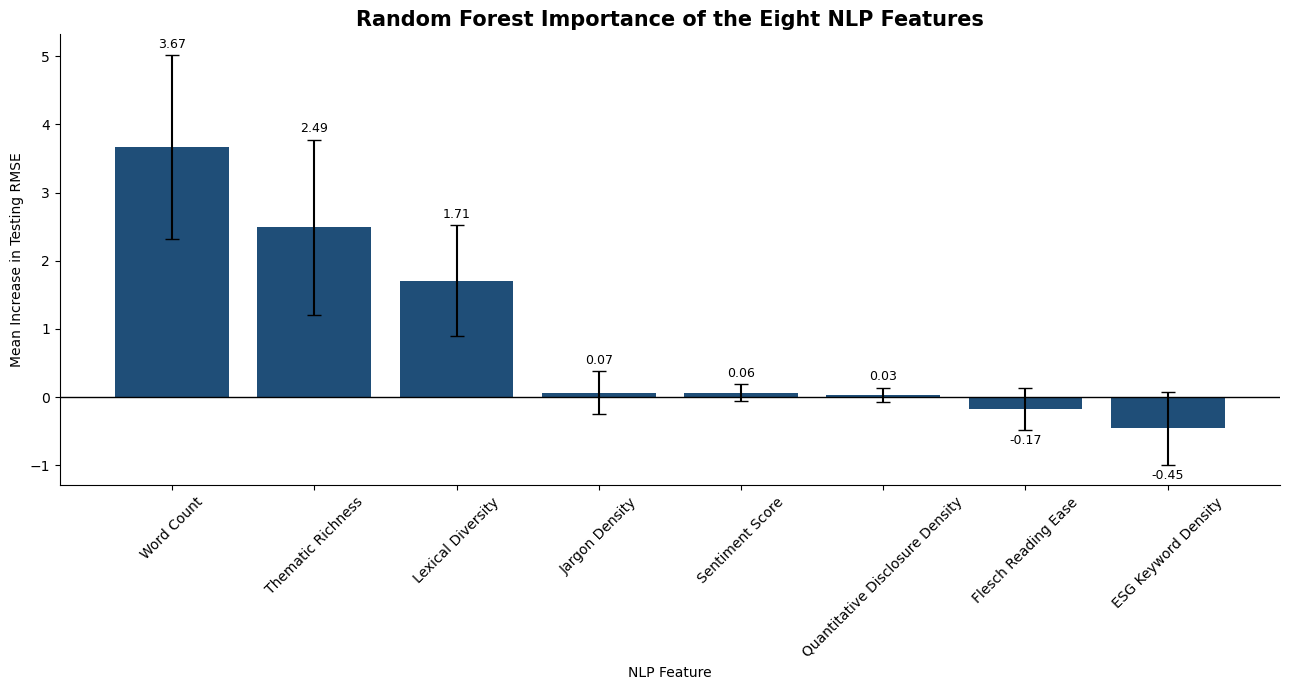

Chart saved as: Notebook04_Eight_NLP_Feature_Importance.png


In [23]:
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    nlp_feature_importance["Feature"],
    nlp_feature_importance["Mean Increase in RMSE"],
    yerr=nlp_feature_importance["Standard Deviation"],
    color=PROJECT_COLOUR,
    capsize=5
)

ax.axhline(
    0,
    color="black",
    linewidth=1
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value in nlp_feature_importance[
            "Mean Increase in RMSE"
        ]
    ],
    padding=3,
    fontsize=9
)

ax.set_title(
    "Random Forest Importance of the Eight NLP Features",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("NLP Feature")
ax.set_ylabel("Mean Increase in Testing RMSE")
ax.tick_params(axis="x", rotation=45)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

importance_chart = (
    OUTPUT_FOLDER
    / "Notebook04_Eight_NLP_Feature_Importance.png"
)

plt.savefig(
    importance_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved as: {importance_chart.name}")

### Interpretation of the Random Forest Feature-Importance Chart

The chart confirms that Word Count, Thematic Richness and Lexical Diversity make the largest contributions to Random Forest prediction accuracy. When Word Count is randomly shuffled, testing RMSE increases by an average of 3.67 points. Shuffling Thematic Richness and Lexical Diversity increases RMSE by approximately 2.49 and 1.71 points respectively. The error bars for these three features remain above zero, indicating that their importance is relatively consistent across the repeated permutations.

Jargon Density, Sentiment Score and Quantitative Disclosure Density have importance values close to zero, and their error ranges overlap zero. This indicates that they provide little unique predictive information after the stronger features are included. Flesch Reading Ease and ESG Keyword Density have negative mean values, but this does not represent a negative relationship with reporting quality. It means that shuffling these features does not worsen the model’s predictive performance, suggesting redundancy, instability or limited additional information. The chart measures predictive contribution rather than causality, and correlations among the NLP features may distribute importance between related predictors.

## 20. Generate Out-of-Fold Predictions for External Validation

Five-fold out-of-fold predictions are generated for all 100 companies using the selected Random Forest model. Each company is predicted by a model that is not trained on that company. This reduces prediction leakage and provides a more appropriate dataset for comparison with LSEG ESG scores in Notebook 5.

In [24]:
full_sample_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

out_of_fold_predictions = cross_val_predict(
    final_model,
    X,
    y,
    cv=full_sample_cv,
    n_jobs=-1
)

prediction_output = analysis_df[
    [
        "Final Sample ID",
        "Company Name",
        "TRBC Sector",
        "LSEG ESG Score"
    ]
].copy()

prediction_output["Actual Final RQI"] = y.values
prediction_output["Predicted Final RQI"] = (
    np.clip(out_of_fold_predictions, 0, 100)
)
prediction_output["Prediction Error"] = (
    prediction_output["Actual Final RQI"]
    - prediction_output["Predicted Final RQI"]
)
prediction_output["Absolute Error"] = (
    prediction_output["Prediction Error"].abs()
)
prediction_output["Selected Model"] = final_model_name

final_oof_metrics = pd.DataFrame([{
    "Model": final_model_name,
    "Companies": len(prediction_output),
    **regression_metrics(
        prediction_output["Actual Final RQI"],
        prediction_output["Predicted Final RQI"]
    )
}])

prediction_file = (
    DATA_FOLDER / "Notebook05_Final_Model_Predictions.xlsx"
)

with pd.ExcelWriter(
    prediction_file,
    engine="openpyxl"
) as writer:
    prediction_output.to_excel(
        writer,
        sheet_name="Model Predictions",
        index=False
    )
    final_oof_metrics.to_excel(
        writer,
        sheet_name="Out-of-Fold Performance",
        index=False
    )

print("FINAL OUT-OF-FOLD PERFORMANCE")
print("-" * 40)
print(
    final_oof_metrics
    .round(4)
    .to_string(index=False)
)

print(f"\nPredictions saved as: {prediction_file.name}")

FINAL OUT-OF-FOLD PERFORMANCE
----------------------------------------
        Model  Companies    MAE   RMSE  R-Squared
Random Forest        100 9.5011 11.653     0.7175

Predictions saved as: Notebook05_Final_Model_Predictions.xlsx


### Statistical Interpretation of the Final Out-of-Fold Performance

The final Random Forest model produces out-of-fold predictions for all 100 companies. Under this procedure, each company is predicted by a model that does not use that company during training. The resulting performance therefore provides a more reliable estimate of the model’s ability to predict reporting quality for unseen companies than in-sample training results.

The model records an MAE of 9.50, indicating that its predictions differ from the observed Final RQI by approximately 9.5 points on average. The RMSE of 11.65 is higher than the MAE, showing that a smaller number of companies have comparatively larger prediction errors. The out-of-fold \(R^2\) of 0.718 indicates that the model explains approximately 71.8% of the variation in Final RQI across the full sample. This represents strong, although not perfect, predictive performance and provides evidence that the NLP features can predict a substantial proportion of the differences in reporting quality. The saved out-of-fold predictions are used in Notebook 5 for external validation against LSEG ESG scores.

## 21. Conduct the Final Modelling Audit

The modelling workflow is checked for sample completeness, model availability, prediction validity and successful selection of the final model. The final model comparison, feature importance and external-validation predictions are combined into a reproducibility workbook.

In [25]:
modelling_audit = pd.DataFrame({
    "Audit Check": [
        "Three predictive models completed",
        "Final model selected",
        "Predictions generated for 100 companies",
        "Company predictions are unique",
        "Predictions contain no missing values",
        "Predicted RQI values are within 0–100",
        "Eight NLP feature importance values available",
        "LSEG ESG scores are available"
    ],
    "Result": [
        len(model_performance_tables),
        final_model_name,
        len(prediction_output),
        prediction_output["Company Name"].nunique(),
        int(prediction_output["Predicted Final RQI"].isna().sum()),
        int(
            prediction_output[
                "Predicted Final RQI"
            ].between(0, 100).sum()
        ),
        len(nlp_feature_importance),
        int(prediction_output["LSEG ESG Score"].notna().sum())
    ],
    "Status": [
        "Passed" if len(model_performance_tables) == 3 else "Failed",
        "Passed" if final_model_name else "Failed",
        "Passed" if len(prediction_output) == 100 else "Failed",
        "Passed" if prediction_output["Company Name"].nunique() == 100
        else "Failed",
        "Passed" if prediction_output["Predicted Final RQI"].isna().sum() == 0
        else "Failed",
        "Passed" if prediction_output["Predicted Final RQI"].between(0, 100).all()
        else "Failed",
        "Passed" if len(nlp_feature_importance) == 8 else "Failed",
        "Passed" if prediction_output["LSEG ESG Score"].notna().all()
        else "Failed"
    ]
})

final_audit_file = (
    DATA_FOLDER / "Notebook04_Final_Modelling_Audit.xlsx"
)

with pd.ExcelWriter(
    final_audit_file,
    engine="openpyxl"
) as writer:
    modelling_audit.to_excel(
        writer,
        sheet_name="Audit Summary",
        index=False
    )
    model_comparison.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )
    nlp_feature_importance.to_excel(
        writer,
        sheet_name="Feature Importance",
        index=False
    )
    final_oof_metrics.to_excel(
        writer,
        sheet_name="Final Model Performance",
        index=False
    )

print(
    modelling_audit
    .to_string(index=False)
)

if not modelling_audit["Status"].eq("Passed").all():
    raise ValueError("Notebook 4 final audit failed.")

print("\nNotebook 4 final modelling audit passed.")
print(f"Audit saved as: {final_audit_file.name}")

                                  Audit Check        Result Status
            Three predictive models completed             3 Passed
                         Final model selected Random Forest Passed
      Predictions generated for 100 companies           100 Passed
               Company predictions are unique           100 Passed
        Predictions contain no missing values             0 Passed
        Predicted RQI values are within 0–100           100 Passed
Eight NLP feature importance values available             8 Passed
                LSEG ESG scores are available           100 Passed

Notebook 4 final modelling audit passed.
Audit saved as: Notebook04_Final_Modelling_Audit.xlsx


#### Notebook Summary and Reproducibility Note

This notebook conducts the statistical analysis and predictive modelling required to examine whether the eight NLP features predict Final Reporting Quality Index scores across the 100-company sample.

The descriptive analysis shows considerable variation in report length, language, readability, thematic coverage and reporting quality. The Shapiro–Wilk tests indicate that all nine analytical variables depart significantly from normality. Spearman correlation and Kruskal–Wallis testing are therefore used as the principal non-parametric statistical methods. Potential outliers are identified using the interquartile-range method but are retained because they may represent genuine differences in corporate-reporting practices.

Spearman analysis identifies five statistically significant relationships after the Benjamini–Hochberg adjustment. Word Count and Thematic Richness show strong positive relationships with Final RQI. ESG Keyword Density and Jargon Density show moderate positive relationships, while Lexical Diversity shows a strong negative relationship. Quantitative Disclosure Density, Flesch Reading Ease and Sentiment Score do not show statistically significant monotonic relationships with Final RQI.

The predictor-correlation matrix identifies Word Count and Lexical Diversity as the main strongly related predictor pair. Multicollinearity is assessed using the Variance Inflation Factor before the regression model is interpreted. Sector-based analysis shows statistically significant differences in Final RQI across the TRBC sectors, with a large epsilon-squared effect. TRBC Sector is therefore retained as a control variable in all predictive models.

Multiple Linear Regression, Random Forest and XGBoost models are developed using an 80:20 training and testing split, a fixed random seed of 42 and five-fold cross-validation. Although the three models produce similar testing performance, Random Forest records the strongest cross-validation results and is selected as the final model.

Permutation importance identifies Word Count, Thematic Richness and Lexical Diversity as the principal predictors used by the Random Forest model. The remaining features provide limited unique predictive information after the stronger variables and sector control are considered.

The final Random Forest model produces out-of-fold predictions for all 100 companies. It records an MAE of 9.50, RMSE of 11.65 and an R-squared value of 0.718. The model therefore explains approximately 71.8% of the variation in Final RQI while ensuring that each company is predicted by a model that is not trained on that company.

The following principal files are produced:

- `Notebook04_Descriptive_Statistics.xlsx`
- `Notebook04_Normality_Test_Results.xlsx`
- `Notebook04_Outlier_Assessment.xlsx`
- `Notebook04_Spearman_Correlation_Results.xlsx`
- `Notebook04_Predictor_Correlations.xlsx`
- `Notebook04_VIF_Results.xlsx`
- `Notebook04_Sector_Based_RQI_Analysis.xlsx`
- `Notebook04_MLR_Performance.xlsx`
- `Notebook04_Random_Forest_Performance.xlsx`
- `Notebook04_XGBoost_Performance.xlsx`
- `Notebook04_Model_Performance_Comparison.xlsx`
- `Notebook04_Random_Forest_Feature_Importance.xlsx`
- `Notebook04_Final_Modelling_Audit.xlsx`
- `Notebook05_Final_Model_Predictions.xlsx`
- `Notebook04_Analytical_Variable_Distributions.png`
- `Notebook04_Spearman_Correlations_with_Final_RQI.png`
- `Notebook04_NLP_Predictor_Correlation_Matrix.png`
- `Notebook04_Predictive_Model_Performance_Comparison.png`
- `Notebook04_Eight_NLP_Feature_Importance.png`

The modelling workflow is complete and the out-of-fold predictions are ready for external validation against LSEG ESG scores in Notebook 5.
